# Used car price prediction

This particular problem statement is from a kaggle competition , https://www.kaggle.com/competitions/playground-series-s4e9
- Goal : given a set of numerical and categorical features corresponding to the attributes of some used cars, generate a model which can
predict the price of the used cars
- Metrics : The metrics for checking the validity of the predicitons is Root mean squared error 

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
import re
import sys
import warnings
import scipy
import statsmodels
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import xgboost as xgb

In [2]:
warnings.filterwarnings('ignore')
sns.set_style("darkgrid")

In [3]:
# reading the csv files

file_paths = {
      "train":"/Users/rudra_sarkar/Documents/ml-practice/used-car-kaggle/train.csv",
      "test":"/Users/rudra_sarkar/Documents/ml-practice/used-car-kaggle/test.csv"
}

train_df = pd.read_csv(file_paths["train"])
test_df = pd.read_csv(file_paths["test"])

In [4]:
train_df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price
0,0,MINI,Cooper S Base,2007,213000,Gasoline,172.0HP 1.6L 4 Cylinder Engine Gasoline Fuel,A/T,Yellow,Gray,None reported,Yes,4200
1,1,Lincoln,LS V8,2002,143250,Gasoline,252.0HP 3.9L 8 Cylinder Engine Gasoline Fuel,A/T,Silver,Beige,At least 1 accident or damage reported,Yes,4999
2,2,Chevrolet,Silverado 2500 LT,2002,136731,E85 Flex Fuel,320.0HP 5.3L 8 Cylinder Engine Flex Fuel Capab...,A/T,Blue,Gray,None reported,Yes,13900
3,3,Genesis,G90 5.0 Ultimate,2017,19500,Gasoline,420.0HP 5.0L 8 Cylinder Engine Gasoline Fuel,Transmission w/Dual Shift Mode,Black,Black,None reported,Yes,45000
4,4,Mercedes-Benz,Metris Base,2021,7388,Gasoline,208.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,7-Speed A/T,Black,Beige,None reported,Yes,97500


In [5]:
test_df.head()

,id,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title
0,188533,Land,Rover LR2 Base,2015,98000,Gasoline,240.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,6-Speed A/T,White,Beige,None reported,Yes
1,188534,Land,Rover Defender SE,2020,9142,Hybrid,395.0HP 3.0L Straight 6 Cylinder Engine Gasoli...,8-Speed A/T,Silver,Black,None reported,Yes
2,188535,Ford,Expedition Limited,2022,28121,Gasoline,3.5L V6 24V PDI DOHC Twin Turbo,10-Speed Automatic,White,Ebony,None reported,NaN
3,188536,Audi,A6 2.0T Sport,2016,61258,Gasoline,2.0 Liter TFSI,Automatic,Silician Yellow,Black,None reported,NaN
4,188537,Audi,A6 2.0T Premium Plus,2018,59000,Gasoline,252.0HP 2.0L 4 Cylinder Engine Gasoline Fuel,A/T,Gray,Black,None reported,Yes


In [6]:
# since while prediction we'll be using only the test set, it makes sense to use the intersecting set of features from both
# the dataframes for building our models

features = {
      "train":set(train_df.columns),
      "test":set(test_df.columns)
}

In [7]:
print("The features which will be used for building and inference are : ")
features['train'].intersection(features['test'])

The features which will be used for building and inference are : 


{'accident',
 'brand',
 'clean_title',
 'engine',
 'ext_col',
 'fuel_type',
 'id',
 'int_col',
 'milage',
 'model',
 'model_year',
 'transmission'}

In [8]:
# the column 'engine' is a bit descriptive, so we will use this to extract out features

engine_horsepower = train_df['engine'].str.extract(r'(\d+\.?\d*)HP').astype('float')
cylinder_capacity = train_df['engine'].str.extract(r'(\d+\.?\d*)L').astype('float')
vulve_numbers = train_df['engine'].str.extract(r'(\d+)V').astype('float')
n_cylinders = train_df['engine'].str.extract(r'(Straight |V |I |\d+) |Cylinder').astype('float')
injection_type = train_df['engine'].str.extract(r'([A-Z]*I)')
misc_engine = train_df['engine'].str.extract(r'([A-Z]*OH[A-Z]*)')

In [9]:
# first we will get rid of the 'id' columns from both the train and the test df

train_df = train_df.drop('id', axis = 1)
test_df = test_df.drop('id', axis = 1)

# EDA

Text(0.5, 1.0, 'Top 5 models from the entries')

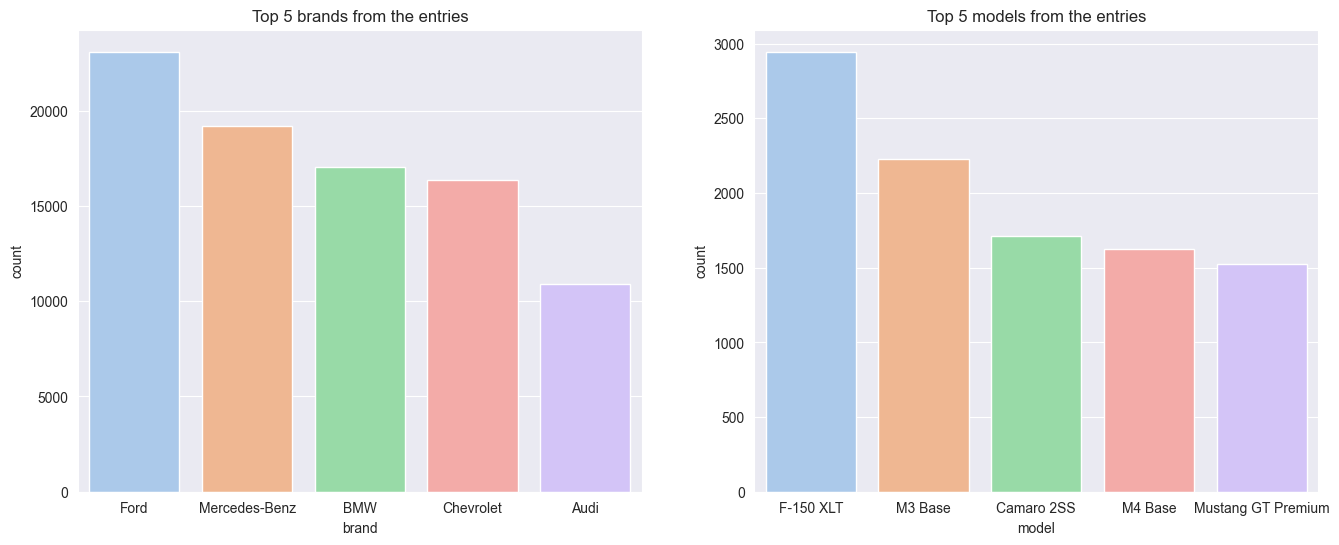

In [10]:
# top 5 brands having the most entries 
fig, ax = plt.subplots(1, 2, figsize = (16, 6))
sns.barplot(train_df['brand'].value_counts()[:5], palette = 'pastel', hue=None, ax = ax[0])
ax[0].set_title("Top 5 brands from the entries")
sns.barplot(train_df['model'].value_counts()[:5], palette = 'pastel', ax = ax[1])
ax[1].set_title("Top 5 models from the entries")

Text(0.5, 1.0, 'Frequency distribution of milage')

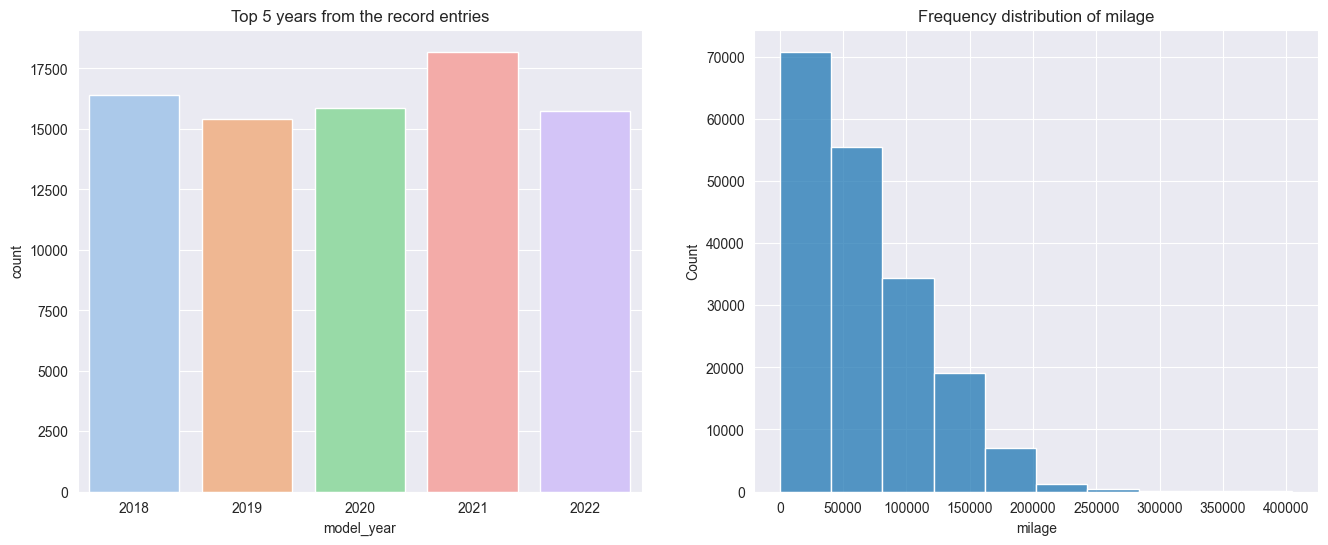

In [11]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))
sns.barplot(train_df['model_year'].value_counts().sort_values(ascending = False)[:5], ax = ax[0], palette = 'pastel')
ax[0].set_title("Top 5 years from the record entries")
sns.histplot(train_df['milage'], bins = 10, palette = 'pastel', ax = ax[1])
ax[1].set_title("Frequency distribution of milage")

Text(0.5, 1.0, 'Top 5 transmission types')

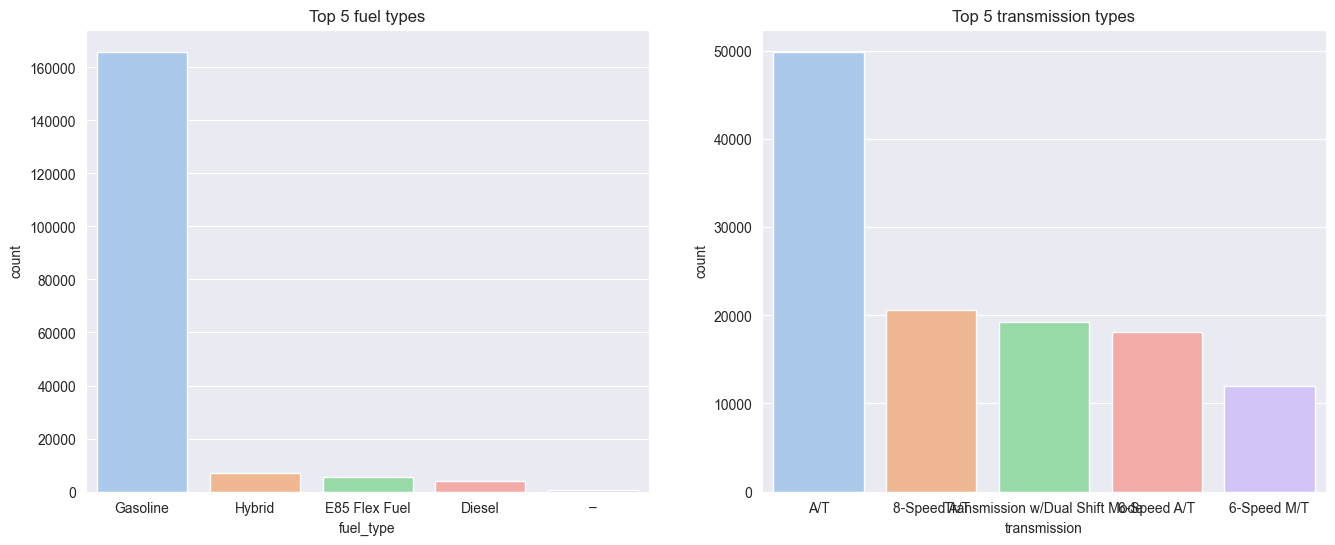

In [12]:
fig, ax = plt.subplots(1, 2, figsize = (16, 6))
sns.barplot(train_df['fuel_type'].value_counts()[:5], palette = 'pastel', ax = ax[0])
ax[0].set_title("Top 5 fuel types")
sns.barplot(train_df['transmission'].value_counts()[:5], palette = 'pastel', ax =ax[1])
ax[1].set_title("Top 5 transmission types")

Text(0.5, 1.0, 'Top 5 int colors')

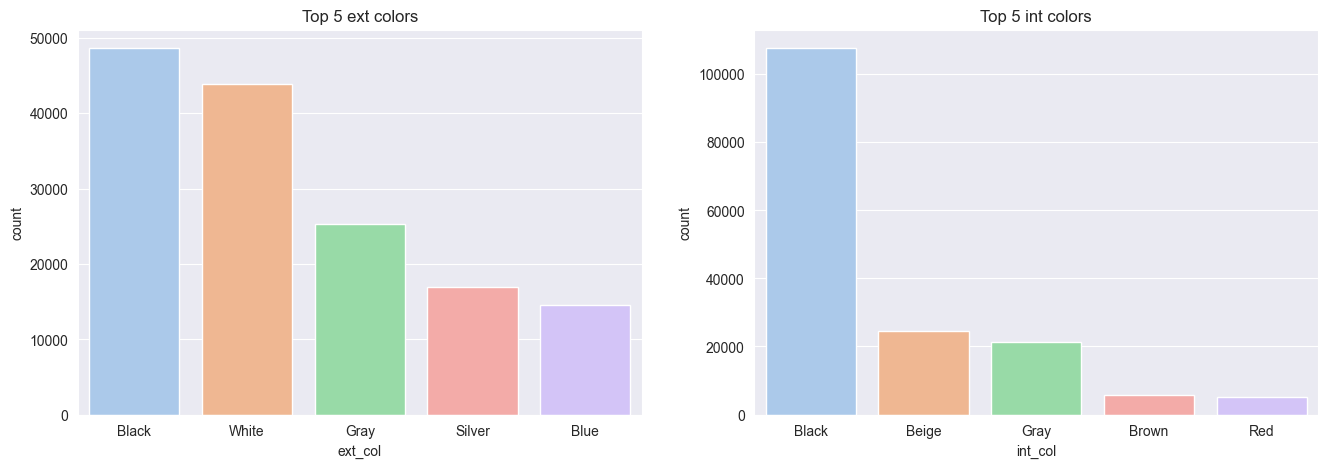

In [13]:
fig, ax = plt.subplots(1, 2, figsize = (16, 5))
sns.barplot(train_df['ext_col'].value_counts()[:5], palette = 'pastel', ax = ax[0])
ax[0].set_title("Top 5 ext colors")
sns.barplot(train_df['int_col'].value_counts()[:5], palette = "pastel", ax = ax[1])
ax[1].set_title("Top 5 int colors")

Text(0.5, 1.0, 'Frequency distribution of horsepower')

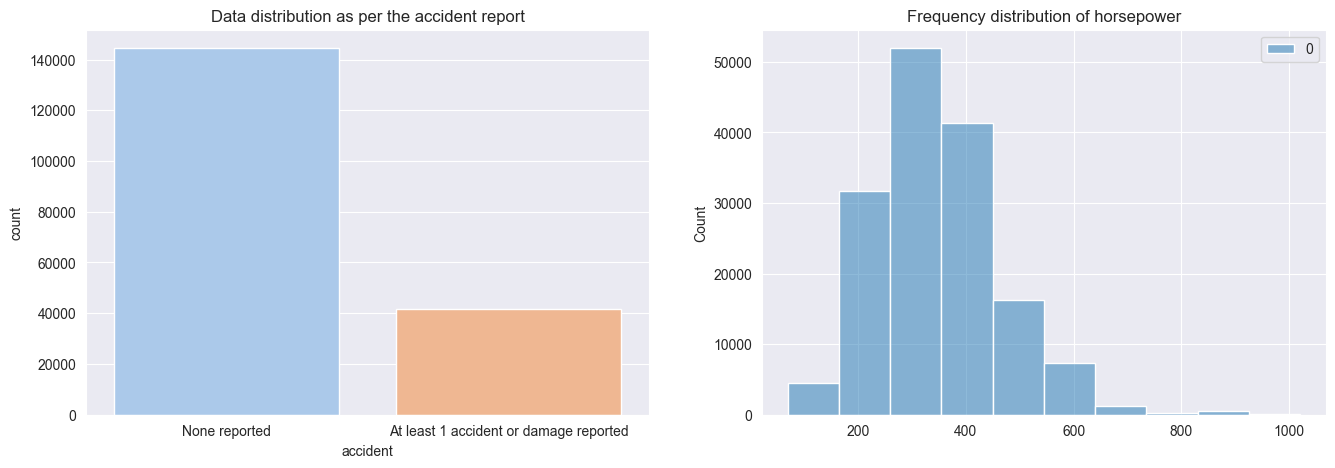

In [14]:
fig, ax = plt.subplots(1, 2, figsize = (16, 5))
sns.barplot(train_df['accident'].value_counts(), palette = 'pastel', ax = ax[0])
ax[0].set_title("Data distribution as per the accident report")
sns.histplot(engine_horsepower, bins=10, ax =ax[1])
ax[1].set_title("Frequency distribution of horsepower")

Text(0.5, 1.0, 'Frequency distribution of number of cylinders')

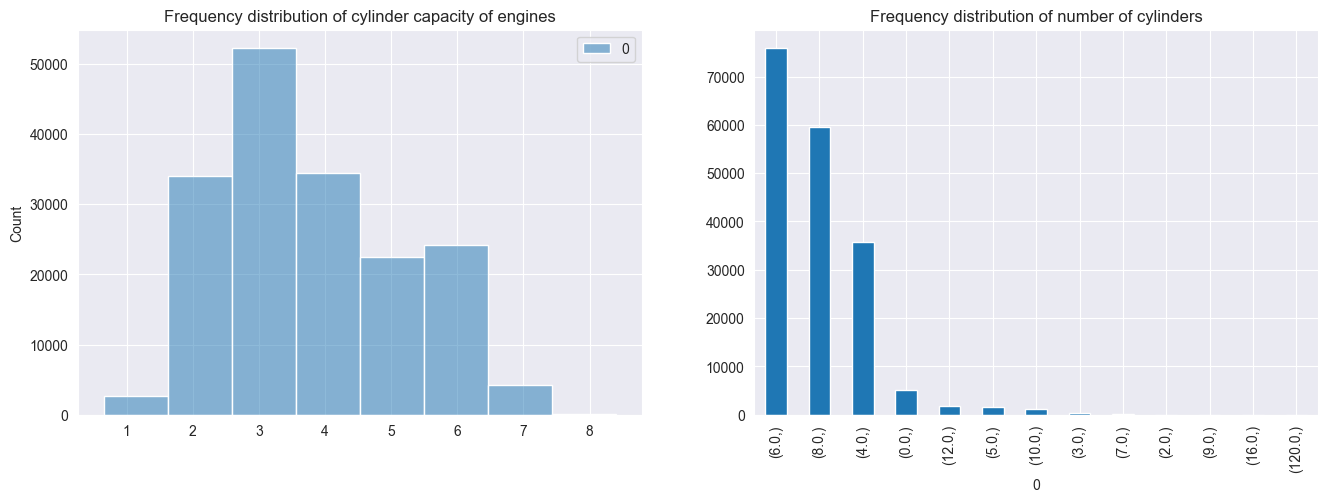

In [15]:
fig, ax = plt.subplots(1, 2, figsize = (16, 5))
sns.histplot(cylinder_capacity, bins=8, ax = ax[0])
ax[0].set_title("Frequency distribution of cylinder capacity of engines")
n_cylinders.value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_title(f"Frequency distribution of number of cylinders")

Text(0.5, 1.0, 'Frequency distribution of over head types')

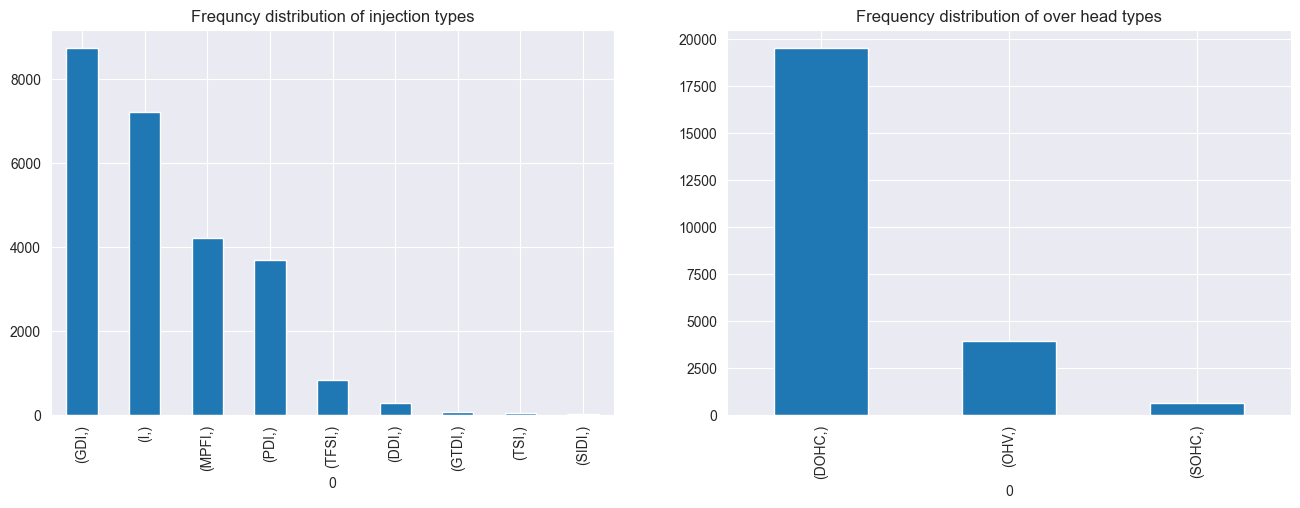

In [16]:
fig, ax = plt.subplots(1, 2, figsize = (16, 5))
injection_type.value_counts().plot(kind = 'bar', ax = ax[0])
ax[0].set_title("Frequncy distribution of injection types")
misc_engine.value_counts().plot(kind = 'bar', ax = ax[1])
ax[1].set_title(f"Frequency distribution of over head types")

In [17]:
def add_features(df, list_of_features, feature_names):
      for feature, feature_name in zip(list_of_features, feature_names):
            df[feature_name] = feature
      return df 
list_of_features = [engine_horsepower, cylinder_capacity, vulve_numbers, n_cylinders, injection_type, misc_engine]
feature_names = ["engine_horsepower", "cylinder_capacity", "vulve_numbers", "n_cylinders", "injection_type", "misc_engine"]
train_df = add_features(train_df, list_of_features, feature_names)

# Imputation

In [18]:
# checking the missing values in the data frame
round(train_df.isna().sum()/len(train_df)*100, 2)

brand                 0.00
model                 0.00
model_year            0.00
milage                0.00
fuel_type             2.70
engine                0.00
transmission          0.00
ext_col               0.00
int_col               0.00
accident              1.30
clean_title          11.36
price                 0.00
engine_horsepower    17.64
cylinder_capacity     7.54
vulve_numbers        87.58
n_cylinders           3.67
injection_type       86.71
misc_engine          87.23
dtype: float64

In [19]:
# as we can see, for the feature "injection type", "misc_engine" and "vulve_numbers" we don't have data for 87% of the time, therefore
# imputing with point estimates might not be a good idea, so we can drop these columns

train_df = train_df.drop(["injection_type", "vulve_numbers", "misc_engine"], axis = 1) 

In [20]:
# for the rest of the features, we can perform imputation 
# we are keeping our imputation simple
# if the feature is a category, we will replace it by the mode
# if the feature is numeric, we will replace it by the median as median is a robust estimate than mean and is not affected by outliers
def simple_impute(df:pd.DataFrame):
      for col in df.columns:
            if df[col].dtype == 'O':
                  df[col].fillna(df[col].mode(), inplace = True)
            elif df[col].dtype in ['int', 'float']:
                  df[col].fillna(df[col].mean(), inplace = True)
      return df

In [21]:
train_df = simple_impute(train_df)

In [22]:
# we can see that the imputation has been completed successfully and now we have no missing values
train_df.isna().sum()

brand                    0
model                    0
model_year               0
milage                   0
fuel_type             5083
engine                   0
transmission             0
ext_col                  0
int_col                  0
accident              2452
clean_title          21419
price                    0
engine_horsepower        0
cylinder_capacity        0
n_cylinders              0
dtype: int64

In [24]:
categorical_features = [i for i in train_df.columns if train_df[i].dtype == 'O']
numerical_features = [i for i in train_df.columns if train_df[i].dtype != 'O']

print(categorical_features)

print(numerical_features)

['brand', 'model', 'fuel_type', 'engine', 'transmission', 'ext_col', 'int_col', 'accident', 'clean_title']
['model_year', 'milage', 'price', 'engine_horsepower', 'cylinder_capacity', 'n_cylinders']


In [25]:
# Now we need to handle the categorical data types
# we will encode the categories to integers
from sklearn.preprocessing import LabelEncoder, OneHotEncoder

def process_categories(df:pd.DataFrame):
      le = LabelEncoder()
      for col in df.columns:
            if df[col].dtype == 'O':
                  df[col] = le.fit_transform(df[col])
      return df

In [26]:
train_df = process_categories(train_df)

In [27]:
train_df.head()

,brand,model,model_year,milage,fuel_type,engine,transmission,ext_col,int_col,accident,clean_title,price,engine_horsepower,cylinder_capacity,n_cylinders
0,31,495,2007,213000,2,116,38,312,71,1,0,4200,172.0,1.6,4.0
1,28,930,2002,143250,2,366,38,263,10,0,0,4999,252.0,3.9,8.0
2,9,1575,2002,136731,1,640,38,38,71,1,0,13900,320.0,5.3,8.0
3,16,758,2017,19500,2,863,49,29,14,1,0,45000,420.0,5.0,8.0
4,36,1077,2021,7388,2,259,23,29,10,1,0,97500,208.0,2.0,4.0


In [28]:
data_attributes = [feature for feature in train_df.columns if feature not in ['price', 'engine']]
target_attribute = 'price'

Text(0.5, 1.0, 'Heatmap to visualtize the correlation amongst various features')

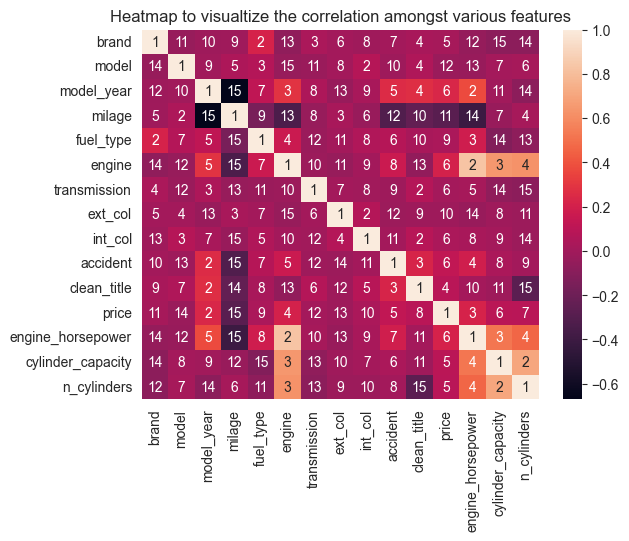

In [29]:
sns.heatmap(train_df.corr(), annot = train_df.corr().rank(method = 'dense', ascending = False, axis = 1))
plt.title("Heatmap to visualtize the correlation amongst various features")

In [30]:
# Correlation with price amongst the other features
train_df.corr()['price']

brand                0.017657
model               -0.029865
model_year           0.231795
milage              -0.283067
fuel_type            0.038596
engine               0.208285
transmission         0.014560
ext_col             -0.017342
int_col              0.035174
accident             0.123034
clean_title          0.089433
price                1.000000
engine_horsepower    0.214364
cylinder_capacity    0.094445
n_cylinders          0.092962
Name: price, dtype: float64

# Hypothesis Test

In [29]:
# We have the correlation values, but we can still go for hypothesis testing before 
# asserting the correlation amongst various features w.r.t price

from statsmodels.stats.weightstats import ztest

def hypothesis_test(feature_name:str, alpha:float):
      simulation = np.array([train_df.sample(n = 40).corr()['price'][feature_name] for _ in range(1000)])
      mean = simulation.mean()
      claim = 0 
      z_stat = abs(claim - mean)/simulation.std()
      p_val = 1 - scipy.stats.norm.cdf(z_stat)
      if p_val > alpha :
            res = "Null Hypothesis accepted : Hence no correlation"
      else:res = "Null hypothesis rejected : Hence there is a correlation"
      return res


In [30]:
test_results = {}
for i in data_attributes:
      test_results[f"{i}"] = [hypothesis_test(i, alpha = 0.05)]

In [31]:
pd.DataFrame(test_results.values(), index = test_results.keys(), columns=['Hypothesis test results'])

,Hypothesis test results
brand,Null Hypothesis accepted : Hence no correlation
model,Null Hypothesis accepted : Hence no correlation
model_year,Null hypothesis rejected : Hence there is a co...
milage,Null hypothesis rejected : Hence there is a co...
fuel_type,Null hypothesis rejected : Hence there is a co...
transmission,Null Hypothesis accepted : Hence no correlation
ext_col,Null Hypothesis accepted : Hence no correlation
int_col,Null Hypothesis accepted : Hence no correlation
accident,Null hypothesis rejected : Hence there is a co...
clean_title,Null hypothesis rejected : Hence there is a co...


In [32]:
features_w_correlation_to_price = {f"{i}":train_df.corr()['price'][i] for i in data_attributes if "rejected" in test_results[i][0] if i!= 'clean_title'}
corr_df = pd.DataFrame(features_w_correlation_to_price.values(), index=features_w_correlation_to_price.keys(), columns = ['correlation'])
corr_df

,correlation
model_year,0.231795
milage,-0.283067
fuel_type,0.038596
accident,0.123034
engine_horsepower,0.214364


([0, 1, 2, 3, 4],
 [Text(0, 0, 'model_year'),
  Text(1, 0, 'milage'),
  Text(2, 0, 'fuel_type'),
  Text(3, 0, 'accident'),
  Text(4, 0, 'engine_horsepower')])

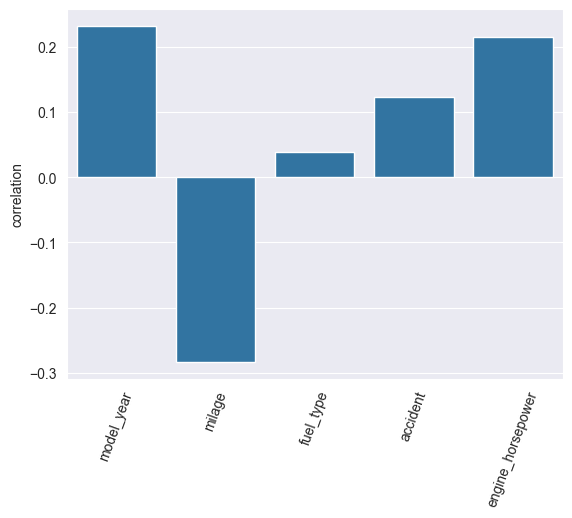

In [33]:
sns.barplot(corr_df['correlation'])
plt.xticks(rotation = 70)

# Model Training and Inference

In [34]:
def extract_HP(df):
      return df['engine'].str.extract(r'(\d+\.?\d*)HP').astype('float')
def extract_cylinder_capacity(df):
      return df['engine'].str.extract(r'(\d+\.?\d*)L').astype('float')
def extract_n_cylinders(df):
      return df['engine'].str.extract(r'(Straight |V |I |\d+) |Cylinder').astype('float')
def feature_extract(df):
      df['engine_horsepower'] = extract_HP(df)
      df['cylinder_capacity'] = extract_cylinder_capacity(df)
      df['n_cylinders'] = extract_n_cylinders(df)
      return df 

def drop_id(df:pd.DataFrame):
      df = df.drop("id", axis = 1)
      return df


def make_dmatrix(X_train, y_train, X_val, y_val):
      dtrain = xgb.DMatrix(X_train, y_train, enable_categorical = True)
      dval = xgb.DMatrix(X_val, y_val, enable_categorical = True)
      return dtrain, dval

def split_data(X, y):
      X_train, X_val, y_train, y_val = train_test_split(X, y, test_size = 0.4, shuffle = True)
      return X_train, y_train, X_val, y_val


In [35]:

def process_data(X):
      X = drop_id(X)
      X = feature_extract(X)
      X = simple_impute(X)
      X = process_categories(X)
      X = StandardScaler().fit_transform(X)
      return X

def generate_DMatrix(X, y=None, purpose='train'):
      if purpose == 'train':
            X_train, y_train, X_val, y_val = split_data(X, y)
            dmatrix = make_dmatrix(X_train, y_train, X_val, y_val)
      elif purpose == 'inference':
            dmatrix = xgb.DMatrix(X, enable_categorical=True)
      return dmatrix

In [36]:
params = {
      "objective": "reg:squarederror",
      'lambda': 0.04,
      'alpha': 0.03,
      'colsample_bytree': 0.6,
      'subsample': 0.9,
      'learning_rate': 0.019,
      'max_depth': 17,
      'random_state': 2024,
      'min_child_weight': 88,
      'n_estimators': 5000,
}



def train_model(X, y):
      X = process_data(X)
      dtrain, dval = generate_DMatrix(X, y, 'train')
      evals = [(dtrain, 'train'), (dval, 'validation')]
      xgb_model = xgb.train(
      params=params,
      dtrain=dtrain,
      num_boost_round=2000,
      evals=evals,
      early_stopping_rounds = 20,
      verbose_eval = 20
      )
      return xgb_model


In [37]:
df = pd.read_csv(file_paths['train'])

In [44]:
model = train_model(df.iloc[:, :len(df.columns)-1], df[target_attribute])

[0]	train-rmse:79908.20720	validation-rmse:76579.01783
[20]	train-rmse:76564.81560	validation-rmse:73593.46469
[40]	train-rmse:74697.84180	validation-rmse:72103.25167
[60]	train-rmse:73526.79177	validation-rmse:71336.16839
[80]	train-rmse:72717.43037	validation-rmse:70941.02568
[100]	train-rmse:72136.14538	validation-rmse:70746.67167
[120]	train-rmse:71667.82888	validation-rmse:70658.00465
[140]	train-rmse:71274.08336	validation-rmse:70622.46881
[160]	train-rmse:70930.09421	validation-rmse:70610.56827
[180]	train-rmse:70609.04305	validation-rmse:70619.07816
[192]	train-rmse:70437.67645	validation-rmse:70631.08515


In [45]:
def predict(X_test):
      X_test = process_data(X_test)
      dmatrix = generate_DMatrix(X_test, purpose = 'inference')
      return model.predict(dmatrix)

In [46]:
test_df = pd.read_csv(file_paths['test'])
test_preds = predict(test_df)

In [47]:
submission = {"id":test_df['id'], 'price':test_preds}

In [48]:
pd.DataFrame(submission).to_csv('./submission.csv', index=False)